# Code to produce Figure 2 from meteorologic and hydrologic data

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

## Load data

In [2]:
AET = np.loadtxt('Data/ETRhourly_RMPmon_20201101_20210430.csv', skiprows=1) # Actual Evapotranspiration = Evap + Transpi 
Inter = np.loadtxt('Data/Intercep_hourly_RMPmon_20201101_20210430.csv', skiprows=1) # Interception 
Qtop = np.loadtxt('Data/Qtop_RMPmon.csv', skiprows=1) # Top flux
precip_eff_phase = np.loadtxt('Data/precip_eff_phase.csv', skiprows=1, delimiter=';') # Effective precipitation phase 

P_rain = precip_eff_phase[:,0]
P_snow = precip_eff_phase[:,1]

piezo_data = np.loadtxt('Data/Piezometers_Pz3b_Pz5b_Data_1hour_20201101_20210430.csv', dtype='str', skiprows=2, delimiter=';') # Water table levels in pz5b and pz2b
z_table = piezo_data[:,-1].astype('float')

In [3]:
h_start = 2082
duration_h = 24*66
h_end = h_start+duration_h

In [ ]:
ndays_numexp = 66

AET_d_numexp = np.zeros(ndays_numexp)
Inter_d_numexp = np.zeros(ndays_numexp)
Qtop_d_numexp = np.zeros(ndays_numexp)
P_rain_d_numexp = np.zeros(ndays_numexp)
P_snow_d_numexp = np.zeros(ndays_numexp)

for i in range(ndays_numexp):
    AET_d_numexp[i] = np.sum(AET[h_start+i*24:h_start+(i+1)*24])
    Inter_d_numexp[i] = np.sum(Inter[h_start+i*24:h_start+(i+1)*24])
    Qtop_d_numexp[i] = np.sum(Qtop[h_start+i*24:h_start+(i+1)*24])
    P_rain_d_numexp[i] = np.sum(P_rain[h_start+i*24:h_start+(i+1)*24])
    P_snow_d_numexp[i] = np.sum(P_snow[h_start+i*24:h_start+(i+1)*24])

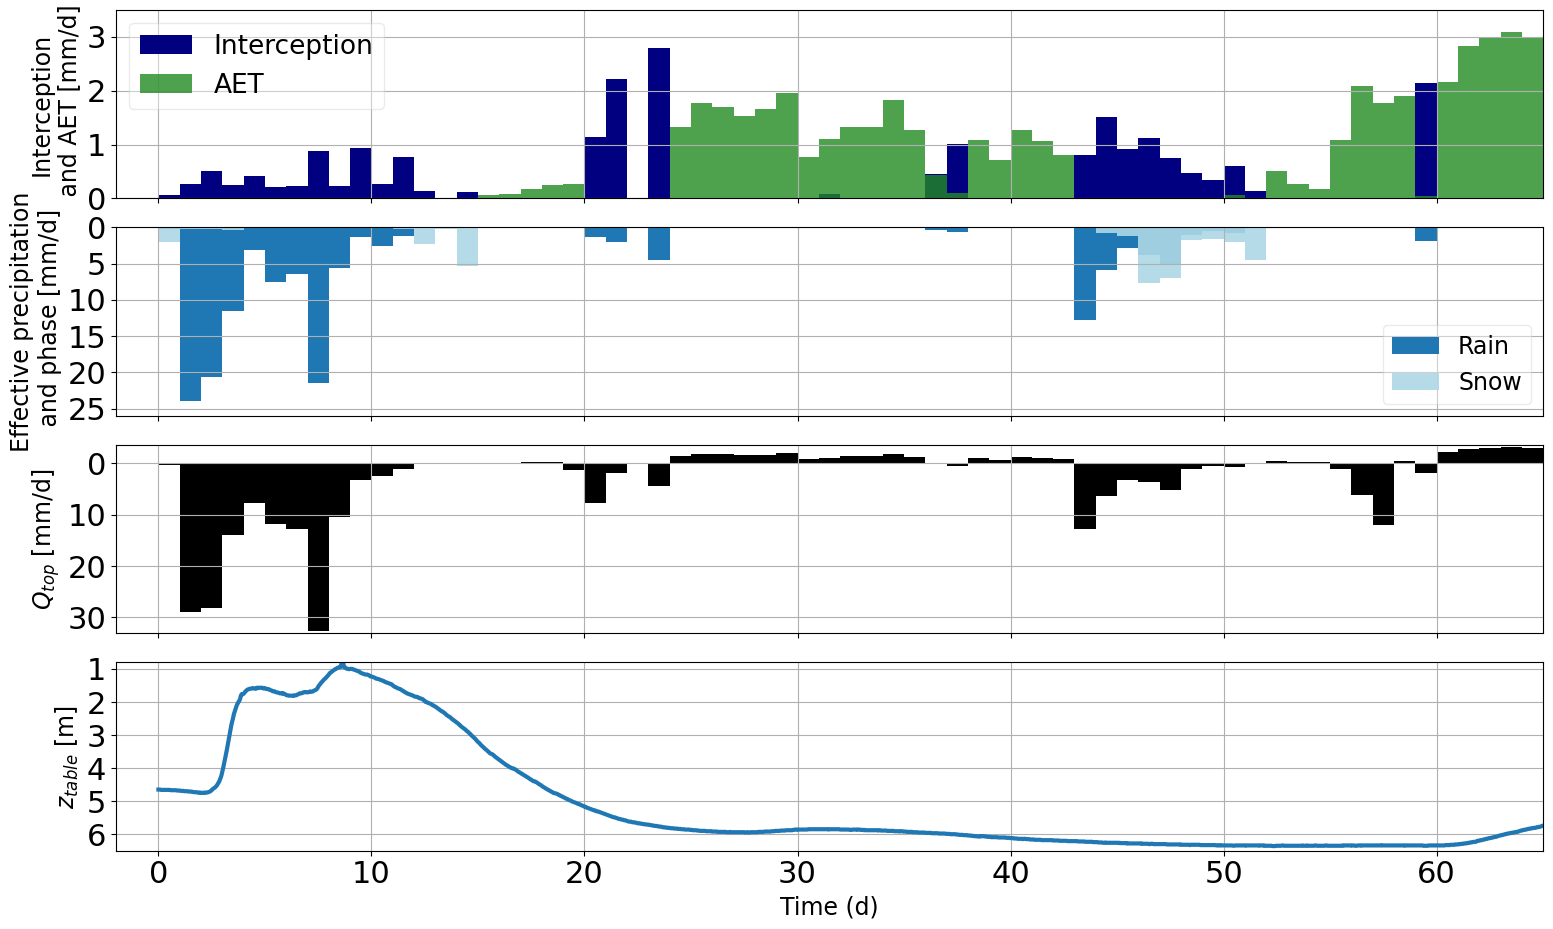

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(15, 9), sharex=True)
fig.tight_layout()
fontsize = 22

# ---------- Convert daily x-values to hourly ----------
nd = ndays_numexp - 1
day_x = np.arange(nd) * 24        # e.g., 0, 24, 48, ...
hour_end = (ndays_numexp - 1) * 24

# ---------- DAY TICKS ----------
day_ticks = np.array([0, 10, 20, 30, 40, 50, 60])
hour_ticks = day_ticks * 24       # convert days → hours

# ======================================================
# Panel 1 — Interception + AET (daily, rescaled to hourly)
# ======================================================
axes[0].bar(day_x, Inter_d_numexp[:-1], width=24, color='navy',
            align='edge', label='Interception')
axes[0].bar(day_x, AET_d_numexp[:-1], width=24, color='forestgreen',
            alpha=0.8, align='edge', label='AET')

axes[0].set_ylim((0, 3.5))
axes[0].set_yticks([0,1,2,3], ['0','1','2','3'], fontsize = fontsize)
axes[0].set_ylabel('Interception\n and AET [mm/d]', fontsize=fontsize-5)
axes[0].legend(fancybox=True, framealpha=0.4, fontsize=fontsize-3)
axes[0].grid()

# ======================================================
# Panel 2 — Rain + Snow (daily → hourly)
# ======================================================
axes[1].bar(day_x, P_rain_d_numexp[:-1], width=24, align='edge', label='Rain')
axes[1].bar(day_x, P_snow_d_numexp[:-1], width=24, align='edge',
            color='#add8e6', alpha=0.9, label='Snow')

axes[1].set_ylim((26, 0))
axes[1].set_yticks([0,5,10,15,20,25], ['0','5','10','15','20','25'], fontsize = fontsize)
axes[1].set_ylabel('Effective precipitation\n and phase [mm/d]',
                   fontsize=fontsize-5)
axes[1].legend(fancybox=True, framealpha=0.4, fontsize=fontsize-5)
axes[1].grid()

# ======================================================
# Panel 3 — Qtop (daily → hourly)
# ======================================================
axes[2].bar(day_x, Qtop_d_numexp[:-1], width=24, color='k', align='edge')
axes[2].set_ylim((max(Qtop_d_numexp)+0.5, min(Qtop_d_numexp)-0.5))
axes[2].set_yticks([0,10,20,30], ['0','10','20','30'], fontsize = fontsize)
axes[2].set_ylabel(r'$Q_{top}$ [mm/d]', fontsize=fontsize-5)
axes[2].grid()

# ======================================================
# Panel 4 — z_table (hourly data)
# ======================================================
axes[3].plot(z_table[h_start:h_end], linewidth=3)
axes[3].set_ylim((6.5, 0.8))
axes[3].set_yticks([1,2,3,4,5,6], ['1','2','3','4','5','6'], fontsize = fontsize)
axes[3].set_ylabel(r'$z_{table}$ [m]', fontsize=fontsize-5)
axes[3].set_xlabel('Time (d)', fontsize=fontsize-5)
axes[3].grid()

# ======================================================
# Apply aligned ticks to ALL axes
# ======================================================

# Blank ticks in upper panels
for ax in axes[:3]:
    ax.set_xticks(hour_ticks)
    ax.set_xticklabels([''] * len(day_ticks))

axes[3].set_xticks(hour_ticks, day_ticks.astype(str), fontsize=fontsize)

for ax in axes:
    ax.set_xlim(-2*24, hour_end)

plt.savefig('Figures/Qtop_fullgraph_numexp_2.jpg', dpi = 300, bbox_inches='tight')